In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("mobile_game_inapp_purchases.csv")
df.head()

,UserID,Age,Gender,Country,Device,GameGenre,SessionCount,AverageSessionLength,SpendingSegment,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall,PaymentMethod,LastPurchaseDate
0,c9889ab0-9cfc-4a75-acd9-5eab1df0015c,49.0,Male,Norway,Android,Battle Royale,9,12.83,Minnow,11.40,28.0,Apple Pay,2025-03-19
1,7c9e413c-ecca-45f2-a780-2826a07952a2,15.0,Male,Switzerland,iOS,Action RPG,11,19.39,Minnow,6.37,18.0,Debit Card,2025-06-08
2,fd61e419-1a92-4f43-a8c7-135842ad328a,23.0,Male,China,Android,Fighting,9,8.87,Minnow,15.81,30.0,Apple Pay,2025-06-02
3,bdb7f6d1-ff9a-468c-afe7-43f32a94293e,31.0,Male,Mexico,Android,Racing,12,19.56,Minnow,13.49,9.0,Debit Card,2025-04-01
4,aa7eec14-4846-47b9-b879-9c98038cda04,37.0,Female,India,Android,Battle Royale,10,15.23,Minnow,10.86,15.0,Paypal,2025-05-05


In [3]:
df.columns

Index(['UserID', 'Age', 'Gender', 'Country', 'Device', 'GameGenre',
       'SessionCount', 'AverageSessionLength', 'SpendingSegment',
       'InAppPurchaseAmount', 'FirstPurchaseDaysAfterInstall', 'PaymentMethod',
       'LastPurchaseDate'],
      dtype='object')

In [4]:
df.shape

(3024, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   UserID                         3024 non-null   object 
 1   Age                            2964 non-null   float64
 2   Gender                         2964 non-null   object 
 3   Country                        2964 non-null   object 
 4   Device                         2964 non-null   object 
 5   GameGenre                      2964 non-null   object 
 6   SessionCount                   3024 non-null   int64  
 7   AverageSessionLength           3024 non-null   float64
 8   SpendingSegment                3024 non-null   object 
 9   InAppPurchaseAmount            2888 non-null   float64
 10  FirstPurchaseDaysAfterInstall  2888 non-null   float64
 11  PaymentMethod                  2888 non-null   object 
 12  LastPurchaseDate               2888 non-null   o

In [6]:
df.describe()

,Age,SessionCount,AverageSessionLength,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall
count,2964.000000,3024.000000,3024.000000,2888.000000,2888.000000
mean,33.533738,10.074735,20.073978,102.582864,15.384003
std,11.992258,3.115863,8.585208,454.339708,8.946191
min,13.000000,1.000000,5.010000,0.000000,0.000000
25%,23.000000,8.000000,12.680000,5.987500,8.000000
50%,33.000000,10.000000,20.315000,11.975000,16.000000
75%,44.000000,12.000000,27.420000,17.762500,23.000000
max,54.000000,22.000000,34.990000,4964.450000,30.000000


In [7]:
df.isnull().sum()

UserID                             0
Age                               60
Gender                            60
Country                           60
Device                            60
GameGenre                         60
SessionCount                       0
AverageSessionLength               0
SpendingSegment                    0
InAppPurchaseAmount              136
FirstPurchaseDaysAfterInstall    136
PaymentMethod                    136
LastPurchaseDate                 136
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['InAppPurchaseAmount'] = df['InAppPurchaseAmount'].fillna(0)
df['FirstPurchaseDaysAfterInstall'] = df['FirstPurchaseDaysAfterInstall'].fillna(-1)
df['LastPurchaseDate'] = df['LastPurchaseDate'].fillna('None')
df['Gender'] = df['Gender'].fillna('Unknown')
df['Country'] = df['Country'].fillna('Unknown')
df['Device'] = df['Device'].fillna('Unknown')
df['PaymentMethod'] = df['PaymentMethod'].fillna('None')
df['GameGenre'] = df['GameGenre'].fillna('Unknown')

In [10]:
df.isnull().sum()

UserID                           0
Age                              0
Gender                           0
Country                          0
Device                           0
GameGenre                        0
SessionCount                     0
AverageSessionLength             0
SpendingSegment                  0
InAppPurchaseAmount              0
FirstPurchaseDaysAfterInstall    0
PaymentMethod                    0
LastPurchaseDate                 0
dtype: int64

In [11]:
df['LastPurchaseDate'] = pd.to_datetime(df['LastPurchaseDate'], errors='coerce')

In [12]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

In [13]:
print(f"Numerical Columns: {numerical_columns}")
print(f"Categorical Columns: {categorical_columns}")

Numerical Columns: Index(['Age', 'SessionCount', 'AverageSessionLength', 'InAppPurchaseAmount',
       'FirstPurchaseDaysAfterInstall'],
      dtype='object')
Categorical Columns: Index(['UserID', 'Gender', 'Country', 'Device', 'GameGenre', 'SpendingSegment',
       'PaymentMethod'],
      dtype='object')


In [14]:
for col in categorical_columns:
    if col != 'UserID':
        print(f"\nUnique Values for {col}:")
        print(df[col].value_counts())


Unique Values for Gender:
Gender
Male       1810
Female     1098
Unknown      60
Other        56
Name: count, dtype: int64

Unique Values for Country:
Country
India           242
Switzerland     119
Saudi Arabia    116
Mexico          115
Netherlands     114
Germany         114
Australia       113
Japan           112
Italy           112
UK              108
Norway          107
USA             107
Denmark         106
Sweden          106
Brazil          105
Iran            105
Canada          105
South Korea     103
China           101
Bangladesh      101
Egypt           101
Spain            96
Afghanistan      93
Russia           93
France           92
Turkey           90
Sri Lanka        88
Unknown          60
Name: count, dtype: int64

Unique Values for Device:
Device
Android    1738
iOS        1226
Unknown      60
Name: count, dtype: int64

Unique Values for GameGenre:
GameGenre
Simulation       219
Sandbox          219
Sports           217
Casual           209
Puzzle           206
C

In [15]:
total_users = df['UserID'].nunique()
total_revenue = df['InAppPurchaseAmount'].sum()
avg_revenue_per_user = df.groupby('UserID')['InAppPurchaseAmount'].sum().mean()
print(f"Total Users: {total_users}")
print(f"Total Revenue: {total_revenue}")
print(f"Avg Revenue Per User: {avg_revenue_per_user}")

Total Users: 3024
Total Revenue: 296259.31000000006
Avg Revenue Per User: 97.96934854497354


In [16]:
pivot_table = df.pivot_table(
    index= 'GameGenre',
    columns = "SpendingSegment",
    values = ['InAppPurchaseAmount'],
    aggfunc= 'mean'
).round(2)

In [17]:
pivot_table

InAppPurchaseAmount                
SpendingSegment             Dolphin Minnow    Whale
GameGenre                                          
Action RPG                   217.75   9.62  1198.20
Adventure                    246.86   8.88  4930.28
Battle Royale                236.60   9.17  2955.91
Card                         237.52   9.87  3291.58
Casual                       261.96  10.62  1266.05
Fighting                     260.47   9.17  3565.38
MMORPG                       234.55   9.15  3374.39
MOBA                         195.02  10.07  3632.84
Puzzle                       190.66  10.32  2106.39
Racing                       254.20   9.82  2504.47
Role Playing                 207.91   8.88  2644.04
Sandbox                      242.93   8.97  1804.61
Simulation                   218.52  10.28  2336.87
Sports                       246.01   9.32  2436.61
Strategy                     210.82   9.34  2582.24
Unknown                      266.24   9.59  3382.23

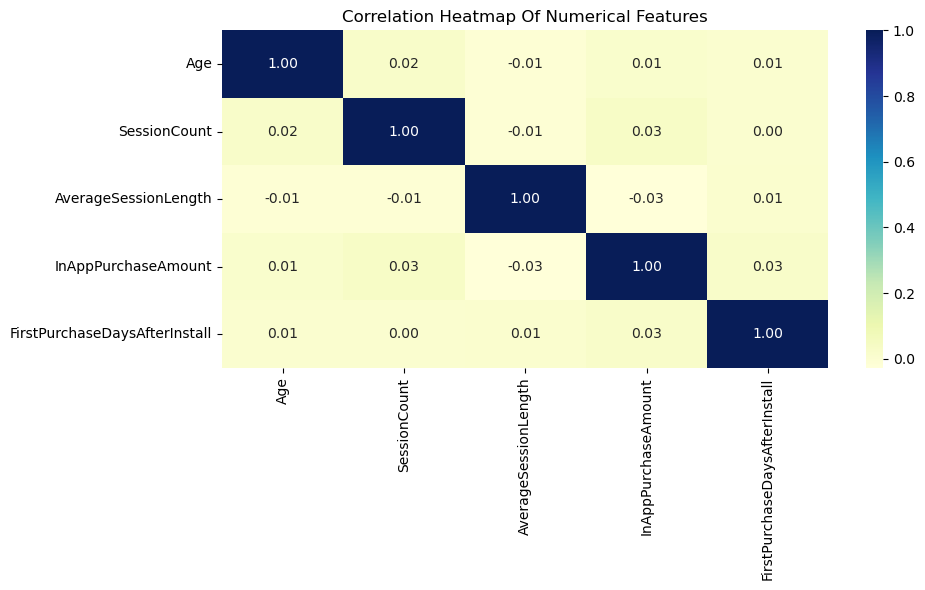

In [18]:
corr_matrix = df[numerical_columns].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title("Correlation Heatmap Of Numerical Features")
plt.tight_layout()

In [19]:
df.columns

Index(['UserID', 'Age', 'Gender', 'Country', 'Device', 'GameGenre',
       'SessionCount', 'AverageSessionLength', 'SpendingSegment',
       'InAppPurchaseAmount', 'FirstPurchaseDaysAfterInstall', 'PaymentMethod',
       'LastPurchaseDate'],
      dtype='object')

In [20]:
SpendingPerSegment = df.groupby("SpendingSegment")['InAppPurchaseAmount'].sum()

In [21]:
SpendingPerSegment

SpendingSegment
Dolphin     96288.80
Minnow      24387.37
Whale      175583.14
Name: InAppPurchaseAmount, dtype: float64

Text(0.5, 1.0, 'Purchase Amount Per User Segment')

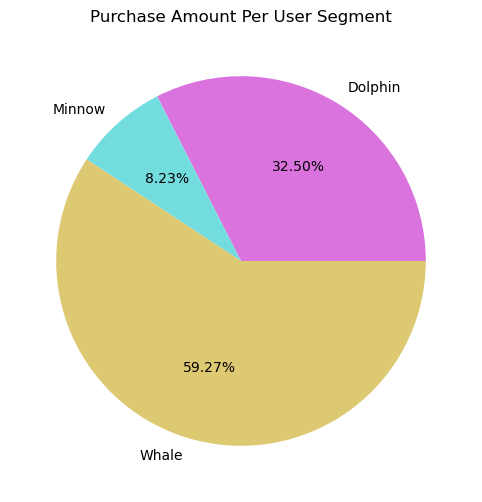

In [22]:
plt.figure(figsize=(10, 6))
plt.pie(SpendingPerSegment, labels=SpendingPerSegment.index,colors=['#DA73DE', '#73DCDE', '#DEC973'], autopct='%1.2f%%')
plt.title("Purchase Amount Per User Segment")

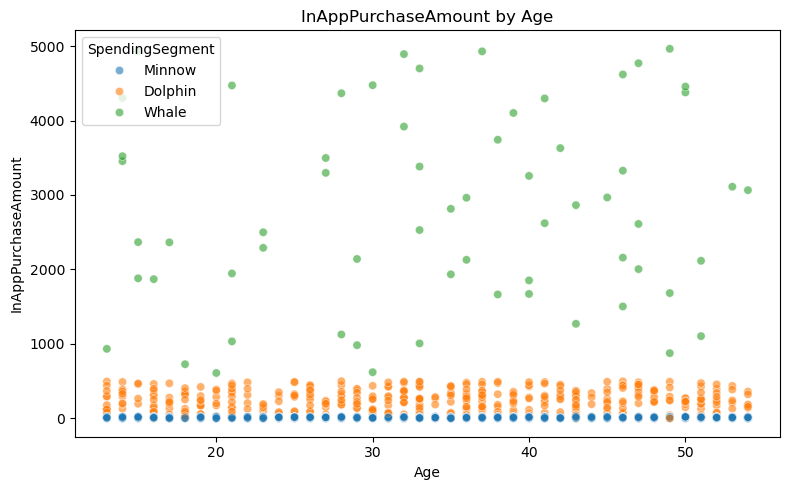

In [29]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Age", y="InAppPurchaseAmount", hue="SpendingSegment", data=df, alpha=0.6)
plt.title("InAppPurchaseAmount by Age")
plt.ylabel("InAppPurchaseAmount")
plt.xlabel("Age")
plt.tight_layout()

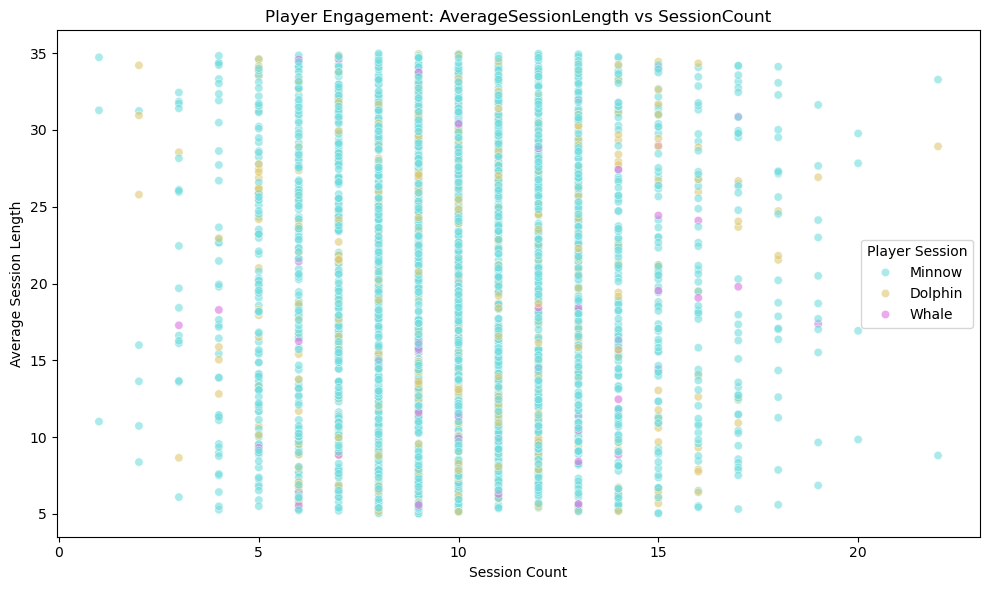

In [33]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="SessionCount", y="AverageSessionLength", hue="SpendingSegment", data=df, alpha=0.6, palette={'Minnow': '#73DCDE', 'Dolphin': '#DEC973', 'Whale': '#DA73DE'})
plt.title("Player Engagement: AverageSessionLength vs SessionCount")
plt.ylabel("Average Session Length")
plt.xlabel("Session Count")
plt.legend(title='Player Session')
plt.tight_layout()

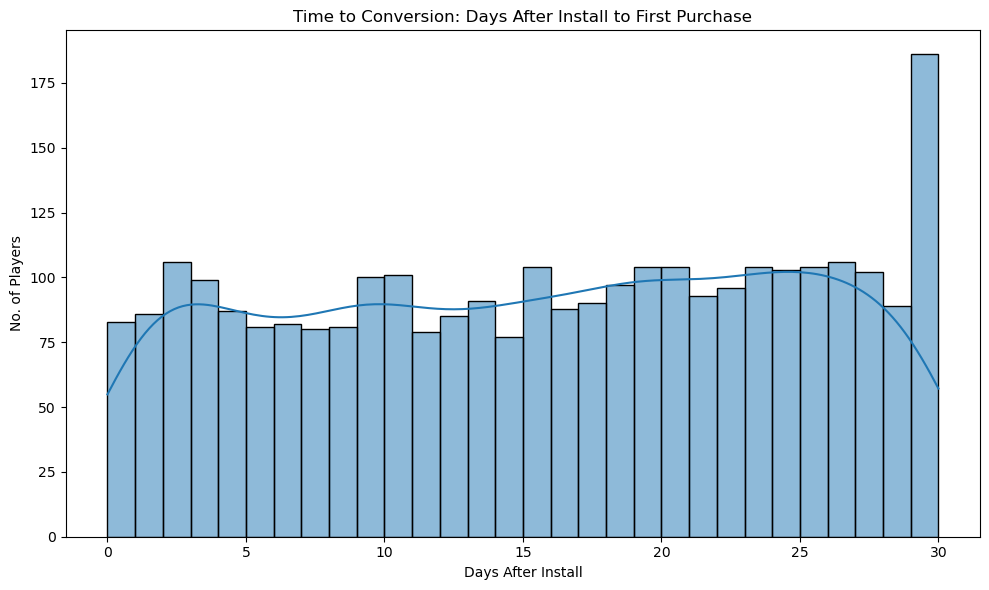

In [34]:
plt.figure(figsize=(10, 6))
conversion_df = df[df['FirstPurchaseDaysAfterInstall'] >= 0]
sns.histplot(conversion_df, x='FirstPurchaseDaysAfterInstall', bins=30, kde=True)
plt.title("Time to Conversion: Days After Install to First Purchase")
plt.xlabel("Days After Install")
plt.ylabel("No. of Players")
plt.tight_layout()

In [43]:
average_revenue_per_country = df.groupby('Country')['InAppPurchaseAmount'].mean().sort_values(ascending=False).reset_index(name='average_revenue')

C:\Users\akash\AppData\Local\Temp\ipykernel_20680\2162622727.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='average_revenue',y='Country', data=average_revenue_per_country, palette='viridis')


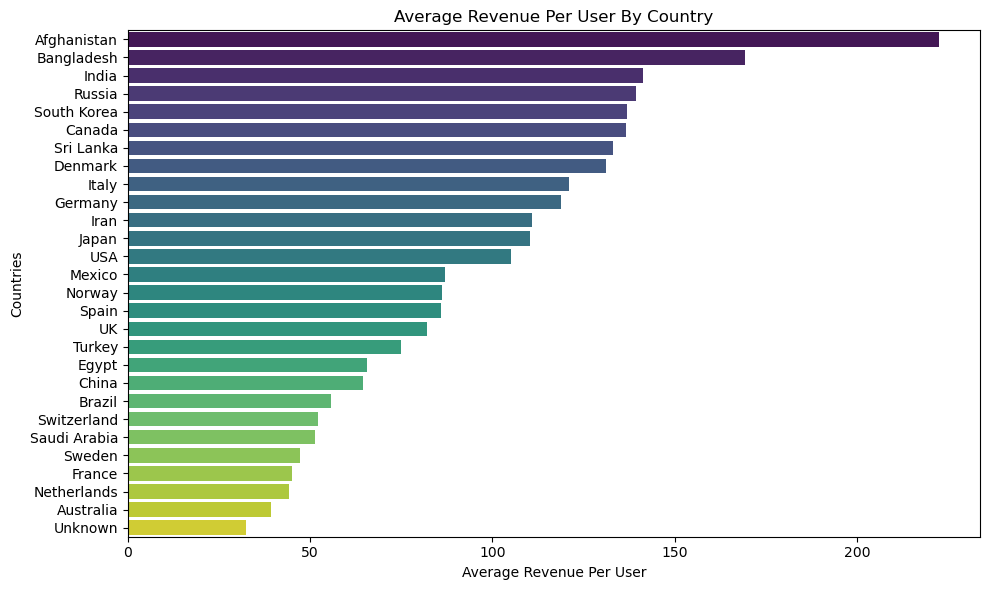

In [46]:
plt.figure(figsize=(10, 6))
sns.barplot(x='average_revenue',y='Country', data=average_revenue_per_country, palette='viridis')
plt.title("Average Revenue Per User By Country")
plt.xlabel("Average Revenue Per User")
plt.ylabel("Countries")
plt.tight_layout()